# Day 4 - ?????????

? one-factor scans ????????????????????? trade-off?

?? notebook ????????????????????????????????????

In [1]:
import importlib
import sys
from pathlib import Path

import pandas as pd
from IPython.display import display

ROOT = Path.cwd()
while not (ROOT / "pyproject.toml").exists() and ROOT.parent != ROOT:
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / "notebooks" / "tutorials"))

tu = importlib.import_module("tutorial_utils")

pd.set_option("display.precision", 4)
OUTPUT_DIR = tu.ensure_output(4)
print("project root:", ROOT)
print("output dir:", OUTPUT_DIR)

project root: D:\Projects\ChemWorld
output dir: D:\Projects\ChemWorld\runs\tutorials\day04


## ????

????????????????????????????????????????????????????????????????

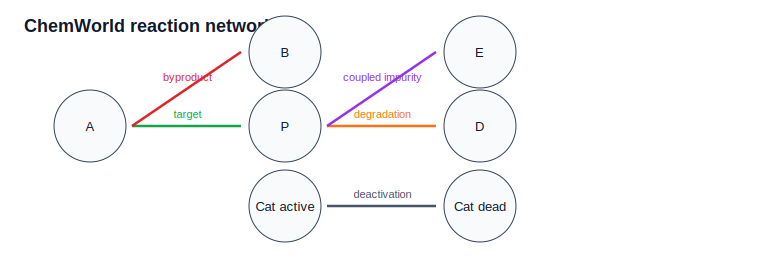

In [2]:
tu.display_tutorial_header(
    day=4,
    title='?????????',
    subtitle='? one-factor scans ????????????????????? trade-off?',
    focus=[
        'temperature scan',
        'time scan',
        'catalyst-solvent interaction',
        'risk-score trade-off',
    ],
    deliverables=[
        '???????',
        '??????',
        '?????????',
    ],
    project_link='?????????????????? leaderboard ???????',
)
tu.display_course_map(4)
display(tu.reaction_network_svg())


In [3]:
tu.display_api_card()

In [4]:
tu.display_student_checkpoint(
    4,
    [
        "one trajectory table or JSONL artifact",
        "one figure generated from your own run",
        "one chemical hypothesis",
        "one proposed next experiment",
        "one note on how GPT or another assistant was used",
    ],
)

,temperature_C,yield,conversion,degradation,risk,score
0,30.0,0.8432,0.9288,0.0119,0.1019,0.6613
1,60.0,0.8804,0.9980,0.0273,0.1042,0.6797
2,90.0,0.7980,1.0000,0.0999,0.1154,0.6138
3,120.0,0.5973,1.0000,0.2881,0.1820,0.4466
4,150.0,0.2888,1.0000,0.5891,0.3370,0.1765


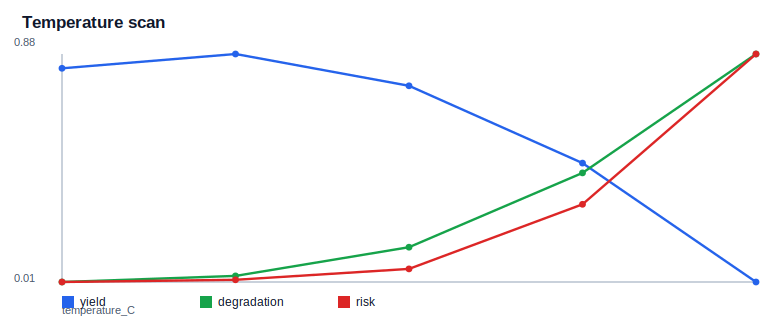

In [5]:
base_recipe = {
    "temperature": 90.0,
    "time": 0.50,
    "initial_concentration": 0.40,
    "stirring_speed": 720.0,
    "catalyst": 1,
    "solvent": 2,
}
temp_rows = []
for temp_c in [30.0, 60.0, 90.0, 120.0, 150.0]:
    recipe = dict(base_recipe, temperature=temp_c)
    temp_rows.append(tu.run_recipe(recipe, seed=31))
temp_df = pd.DataFrame(temp_rows)
display(temp_df[["temperature_C", "yield", "conversion", "degradation", "risk", "score"]])
display(
    tu.line_svg(
        temp_df,
        x="temperature_C",
        ys=["yield", "degradation", "risk"],
        title="Temperature scan",
    )
)

,time_h,yield,conversion,degradation,risk,score
0,0.25,0.8465,1.0,0.0489,0.1154,0.6519
1,0.50,0.7980,1.0,0.0999,0.1154,0.6138
2,1.00,0.7049,1.0,0.1931,0.1154,0.5417
3,2.00,0.5499,1.0,0.3481,0.1154,0.4209
4,4.00,0.3343,1.0,0.5637,0.1154,0.2502
5,8.00,0.3343,1.0,0.5637,0.1154,0.2502


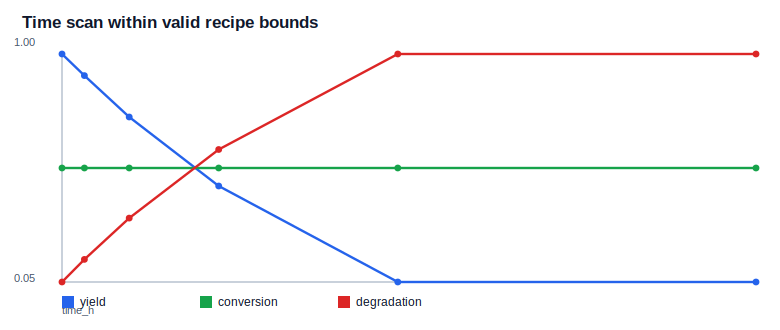

In [6]:
time_rows = []
for time_h in [0.25, 0.50, 1.00, 2.00, 4.00, 8.00]:
    recipe = dict(base_recipe, temperature=90.0, time=time_h)
    time_rows.append(tu.run_recipe(recipe, seed=31))
time_df = pd.DataFrame(time_rows)
display(time_df[["time_h", "yield", "conversion", "degradation", "risk", "score"]])
display(
    tu.line_svg(
        time_df,
        x="time_h",
        ys=["yield", "conversion", "degradation"],
        title="Time scan within valid recipe bounds",
    )
)

In [7]:
early = time_df.head(3)[["yield", "conversion", "degradation", "score"]]
assert early.drop_duplicates().shape[0] == early.shape[0]
display(pd.DataFrame({"time_scan_distinct_first_three": [True]}))

,time_scan_distinct_first_three
0,True


solvent,acetonitrile,ethanol,toluene,water
catalyst,,,,
cat_a,0.6057,0.5519,0.4963,0.6594
cat_b,0.6138,0.5805,0.5496,0.6758
cat_c,0.5471,0.4769,0.4233,0.6097
cat_d,0.6267,0.5924,0.5554,0.6794


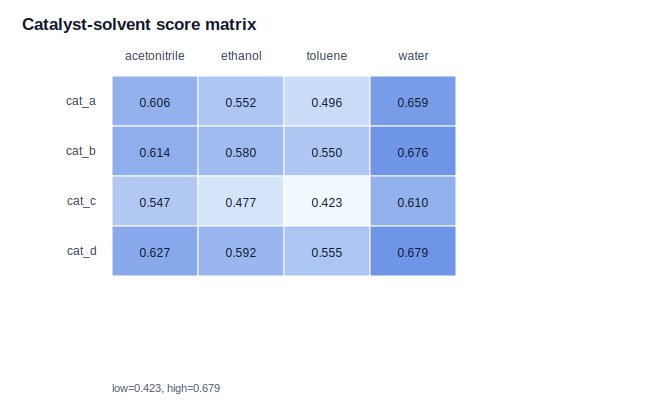

In [8]:
interaction_rows = []
for catalyst in range(len(tu.CATALYSTS)):
    for solvent in range(len(tu.SOLVENTS)):
        recipe = dict(base_recipe, catalyst=catalyst, solvent=solvent)
        interaction_rows.append(tu.run_recipe(recipe, seed=31))
interaction_df = pd.DataFrame(interaction_rows)
score_matrix = interaction_df.pivot(
    index="catalyst",
    columns="solvent",
    values="score",
)
display(score_matrix)
display(tu.heatmap_svg(score_matrix, title="Catalyst-solvent score matrix"))

,initial_concentration_M,yield,conversion,risk,score
0,0.15,0.7093,1.0,0.0973,0.5523
1,0.30,0.7066,1.0,0.1062,0.5464
2,0.60,0.7014,1.0,0.1444,0.5295
3,1.00,0.6944,1.0,0.2285,0.4988
4,1.60,0.6843,1.0,0.2826,0.4709


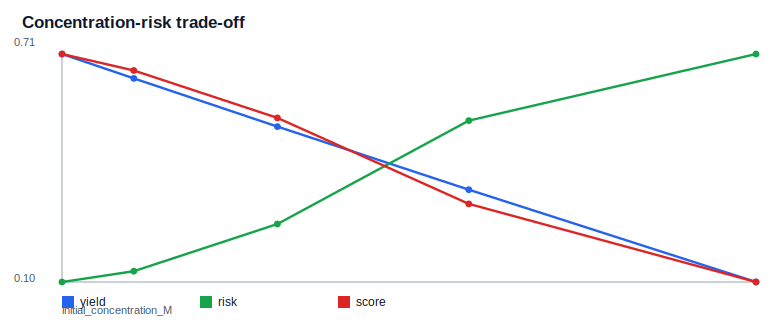

In [9]:
risk_rows = []
for concentration in [0.15, 0.30, 0.60, 1.00, 1.60]:
    recipe = dict(base_recipe, initial_concentration=concentration, time=1.0)
    risk_rows.append(tu.run_recipe(recipe, seed=31))
risk_df = pd.DataFrame(risk_rows)
display(risk_df[["initial_concentration_M", "yield", "conversion", "risk", "score"]])
display(
    tu.line_svg(
        risk_df,
        x="initial_concentration_M",
        ys=["yield", "risk", "score"],
        title="Concentration-risk trade-off",
    )
)

## 当天练习

根据三张图写出两个假设：

- 一个关于“如何提高产率”的假设；
- 一个关于“如何降低风险或降解”的假设。

明天我们会用 surrogate model 把这些假设变成候选实验。


## Exit Ticket

???????????????????????????

In [10]:
tu.display_reflection_box(["????????????", "???????????????????????"])